# Refined Stage 3K - is the benchmark fair? Random-walk robustness (RQ1, RQ3, H4)

Every relMAE in this thesis divides by a **seasonal-naive** benchmark: repeat the value from
one seasonal period ago (m = 48/144/1440 steps at native, 24 hourly, 7 daily). That choice is
load-bearing, and it is questionable in two places:

- **Wind** has no reliable daily cycle. Repeating yesterday's value at the same clock time is a
  weak forecast, so beating it is easy — and wind's strong relMAE may reflect a soft benchmark
  rather than real skill.
- The **cross-granularity** comparison (RQ1) divides each granularity by a *different*
  benchmark. A granularity could "win" merely because its naive opponent is weaker.

This notebook re-scores every existing forecast against a **random-walk** benchmark — repeat
the last observed value — and asks whether the conclusions survive. **No model is run:** only
the denominator changes.

The random walk is the seasonal-naive with m = 1, so the module's own `seasonal_naive` is
reused. The window geometry is rebuilt from the cached panel and joined back to the results by
window key, which is exact because origins are deterministic.

In [1]:
import sys, os, warnings, importlib
warnings.filterwarnings("ignore")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import refined_stage_common as C
importlib.reload(C)
REQUIRED = "2026.09.10-relmae"
assert getattr(C, "__version__", None) == REQUIRED, (
    f"stale refined_stage_common (got {getattr(C, '__version__', 'none')}, "
    f"need {REQUIRED}) -- restart the kernel and Run All")
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 45)
PALETTE = {"chronos": "#2563eb", "timesfm": "#059669", "moirai": "#d97706"}
print(f"common module {C.__version__} from {C.__file__}")

common module 2026.09.10-relmae from e:\Thesis\EnergyForcastModel\refined_stage_common.py


## 1. Reconstruct the random-walk benchmark for every window

`rw_mae` depends only on `(etype, gran, series_id, origin_index, horizon_steps)` — not on the
context length or the model — so it is computed once per unique window geometry and joined onto
all three models' results.

In [2]:
DATA = C.get_data()
FILES = ["refined_stage3b_context_sweep.csv", "refined_stage3c_horizon_sweep.csv",
         "refined_stage3d_fixed_lead_time.csv"]
res = pd.concat([pd.read_csv(f).assign(source=f.split("stage")[1][:2]) for f in FILES if os.path.exists(f)],
                ignore_index=True)
print(f"{len(res):,} model-result rows loaded from {len(FILES)} files")

geo = res[["etype", "gran", "series_id", "origin_index", "horizon_steps"]].drop_duplicates()
print(f"{len(geo):,} unique window geometries to reconstruct")

rw = {}
missing = 0
for et in C.BASE:
    for gk in C.GRANULARITIES:
        sub = geo[(geo.etype == et) & (geo.gran == gk)]
        if sub.empty:
            continue
        panel = C.panel(DATA, et, gk)                 # list of arrays, one per series
        for r in sub.itertuples():
            vals = panel[r.series_id]
            st, h = int(r.origin_index), int(r.horizon_steps)
            truth = vals[st:st + h]
            sn = C.seasonal_naive(vals, st, h, 1)     # m=1  ->  random walk (repeat last value)
            if sn is None or len(truth) < h:
                missing += 1
                continue
            rw[(et, gk, r.series_id, st, h)] = float(np.mean(np.abs(truth - sn)))
print(f"reconstructed rw_mae for {len(rw):,} geometries ({missing} could not be built)")

key = list(zip(res.etype, res.gran, res.series_id, res.origin_index, res.horizon_steps))
res["rw_mae"] = [rw.get(k, np.nan) for k in key]
res["relMAE_rw"] = np.where(res.rw_mae > 0, res.MAE / res.rw_mae, np.nan)
print(f"\nrelMAE_rw attached to {res.relMAE_rw.notna().mean():.1%} of rows")

loaded cached panel <- refined_panel_cache.pkl
  load   5 series, 230,736–232,272 points
  solar  5 series, 52,560–52,560 points
  wind   5 series, 434,876–434,876 points
82,590 model-result rows loaded from 3 files
11,230 unique window geometries to reconstruct
reconstructed rw_mae for 11,230 geometries (0 could not be built)

relMAE_rw attached to 78.3% of rows


## 2. How much stronger is the random walk than the seasonal naive?

If the two benchmarks are similar, the choice does not matter. Where the random walk is much
*stronger* (lower MAE), the seasonal benchmark was flattering the models — and that is exactly
where wind is expected to sit.

In [3]:
cl = res[~res.degenerate].dropna(subset=["relMAE", "relMAE_rw"]).copy()
# snaive_mae is already in the file; ratio > 1 means the random walk is the HARDER benchmark
cl["naive_ratio"] = cl.snaive_mae / cl.rw_mae
tab = (cl.groupby(["etype", "gran"])
         .agg(seasonal_naive_mae=("snaive_mae", "median"),
              random_walk_mae=("rw_mae", "median"),
              ratio_seasonal_over_rw=("naive_ratio", "median")).reset_index())
print("ratio > 1  ->  random walk is HARDER to beat than seasonal naive (benchmark was soft)")
print("ratio < 1  ->  seasonal naive is the harder benchmark (the daily cycle is real)\n")
print(tab.round(3).to_string(index=False))

ratio > 1  ->  random walk is HARDER to beat than seasonal naive (benchmark was soft)
ratio < 1  ->  seasonal naive is the harder benchmark (the daily cycle is real)

etype   gran  seasonal_naive_mae  random_walk_mae  ratio_seasonal_over_rw
 load     1D             180.497          269.338                   0.707
 load     1h             138.248          306.940                   0.459
 load native             118.596          212.605                   0.566
solar     1D               1.842            1.489                   1.187
solar     1h               1.643            4.200                   0.477
solar native               1.425            2.842                   0.844
 wind     1D              12.370           11.540                   1.002
 wind     1h               7.890           13.406                   0.947
 wind native               4.813            2.404                   1.492


## 3. The headline numbers under both benchmarks, side by side

The median relMAE per cell, scored against seasonal-naive (as reported) and against
random-walk. A cell whose relMAE crosses 1.0 between the two columns changes its deployability
verdict, and that must be reported.

In [4]:
comp = (cl.groupby(["etype", "gran"])
          .agg(relMAE_seasonal=("relMAE", "median"),
               relMAE_randomwalk=("relMAE_rw", "median")).reset_index())
comp["delta"] = comp.relMAE_randomwalk - comp.relMAE_seasonal
comp["verdict_flips"] = ((comp.relMAE_seasonal < 1) != (comp.relMAE_randomwalk < 1))
print(comp.round(3).to_string(index=False))
n = int(comp.verdict_flips.sum())
print(f"\n{n} of {len(comp)} cells cross the relMAE = 1 line when the benchmark changes.")
print("Those cells 'beat the benchmark' under one naive and not the other — report both.")
comp.to_csv("refined_stage3k_benchmark_comparison.csv", index=False)

etype   gran  relMAE_seasonal  relMAE_randomwalk  delta  verdict_flips
 load     1D            0.750              0.549 -0.201          False
 load     1h            0.726              0.296 -0.430          False
 load native            0.771              0.444 -0.326          False
solar     1D            0.771              0.934  0.163          False
solar     1h            1.006              0.431 -0.576           True
solar native            1.099              0.959 -0.140           True
 wind     1D            0.991              1.001  0.010           True
 wind     1h            1.046              0.936 -0.110           True
 wind native            0.614              0.994  0.380          False

4 of 9 cells cross the relMAE = 1 line when the benchmark changes.
Those cells 'beat the benchmark' under one naive and not the other — report both.


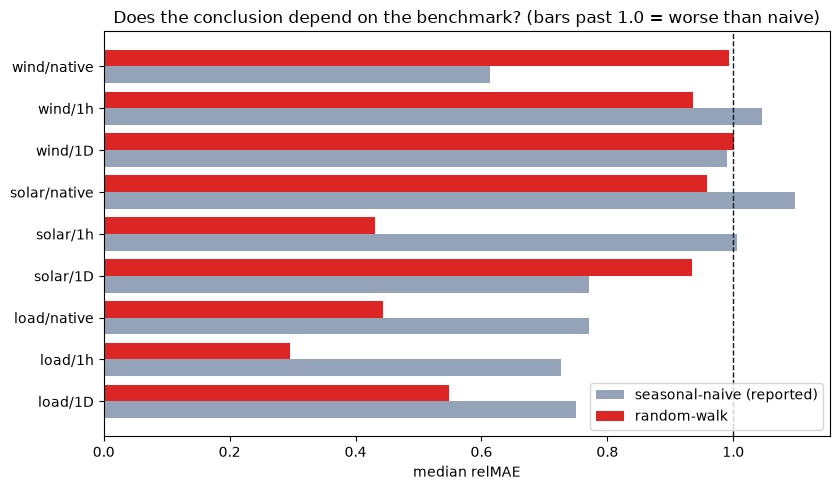

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(comp))
ax.barh(x - 0.2, comp.relMAE_seasonal, height=0.4, label="seasonal-naive (reported)",
        color="#94a3b8")
ax.barh(x + 0.2, comp.relMAE_randomwalk, height=0.4, label="random-walk", color="#dc2626")
ax.axvline(1.0, color="#111827", ls="--", lw=1)
ax.set_yticks(x); ax.set_yticklabels([f"{e}/{g}" for e, g in zip(comp.etype, comp.gran)])
ax.set_xlabel("median relMAE"); ax.legend()
ax.set_title("Does the conclusion depend on the benchmark? (bars past 1.0 = worse than naive)")
plt.tight_layout(); plt.show()

## 4. Does WIND's apparent strength survive?

Wind at native resolution has among the best relMAE in the whole study. If that is an artefact
of a soft seasonal benchmark, wind-native relMAE_rw will rise sharply — perhaps above 1.0. This
cell isolates the question the examiner will ask first.

In [6]:
w = cl[cl.etype == "wind"]
wt = (w.groupby(["gran", "model"])
        .agg(relMAE_seasonal=("relMAE", "median"),
             relMAE_randomwalk=("relMAE_rw", "median")).reset_index())
wt["inflation"] = (wt.relMAE_randomwalk / wt.relMAE_seasonal).round(2)
print("WIND — per model and granularity:\n")
print(wt.round(3).to_string(index=False))
print("\nIf relMAE_randomwalk >> relMAE_seasonal, the seasonal benchmark was flattering wind.")
print("If it stays below 1.0, wind genuinely beats even the random walk and the result holds.")

WIND — per model and granularity:

  gran   model  relMAE_seasonal  relMAE_randomwalk  inflation
    1D chronos            0.995              1.003       1.01
    1D  moirai            0.998              1.002       1.00
    1D timesfm            0.958              0.996       1.04
    1h chronos            1.163              0.920       0.79
    1h  moirai            1.101              1.000       0.91
    1h timesfm            0.975              0.795       0.82
native chronos            0.616              1.000       1.62
native  moirai            0.631              1.000       1.58
native timesfm            0.589              0.982       1.67

If relMAE_randomwalk >> relMAE_seasonal, the seasonal benchmark was flattering wind.
If it stays below 1.0, wind genuinely beats even the random walk and the result holds.


## 5. RQ1 under the random-walk benchmark — does the granularity ordering hold?

The de-confounded 3D comparison, re-derived with relMAE_rw. Any (energy type, history, lead)
row whose winning granularity changes is a place where the RQ1 conclusion depends on the
benchmark, and must be reported with both.

In [7]:
d3d = cl[cl.source == "3d"].copy()
assert not d3d.empty, "no 3D rows found — check the source tag"
def winners(frame, col):
    b = (frame.groupby(["etype", "history", "lead", "gran_label"])[col]
              .median().reset_index().dropna(subset=[col]))
    b = b[b.groupby(["etype", "history", "lead"])[col].transform("size") >= 2]  # real comparisons
    if b.empty:
        return pd.DataFrame()
    i = b.groupby(["etype", "history", "lead"])[col].idxmin()
    return b.loc[i].set_index(["etype", "history", "lead"])["gran_label"].rename(col)

if {"history", "lead"}.issubset(d3d.columns):
    ws = winners(d3d, "relMAE"); wr = winners(d3d, "relMAE_rw")
    j = pd.concat([ws, wr], axis=1).dropna()
    j["changed"] = j.relMAE != j.relMAE_rw
    print("Winning granularity per scenario — seasonal vs random-walk benchmark:\n")
    print(j.to_string())
    print(f"\n{int(j.changed.sum())} of {len(j)} comparable scenarios pick a different "
          f"granularity under the random-walk benchmark.")
    j.to_csv("refined_stage3k_rq1_under_rw.csv")
else:
    print("history/lead columns not present in the pooled frame; skip RQ1 re-derivation.")

Winning granularity per scenario — seasonal vs random-walk benchmark:

                              relMAE         relMAE_rw  changed
etype history lead                                             
load  40 d    1 h             hourly            hourly    False
              24 h             daily  minutes (native)     True
              48 h            hourly            hourly    False
              6 h             hourly            hourly    False
      7 d     1 h   minutes (native)            hourly     True
              24 h            hourly            hourly    False
              6 h             hourly            hourly    False
solar 40 d    24 h             daily            hourly     True
              48 h             daily            hourly     True
      7 d     1 h   minutes (native)            hourly     True
              6 h             hourly            hourly    False
wind  40 d    24 h             daily            hourly     True
              48 h             da

## 6. RQ3 under the random-walk benchmark - does the best model change?

The per-cell best model, under both benchmarks. relMAE_rw changes only the denominator, which
is *shared* by all three models within a window — so per-window model *rankings* are unchanged
by construction. What can change is a *deployability* verdict (relMAE crossing 1.0). This cell
confirms the ranking invariance and flags any verdict change.

In [8]:
best_s = cl.groupby(["etype", "gran"]).apply(
    lambda g: g.groupby("model").relMAE.median().idxmin()).rename("best_seasonal")
best_r = cl.groupby(["etype", "gran"]).apply(
    lambda g: g.groupby("model").relMAE_rw.median().idxmin()).rename("best_rw")
bt = pd.concat([best_s, best_r], axis=1).reset_index()
bt["changed"] = bt.best_seasonal != bt.best_rw
print(bt.to_string(index=False))
print(f"\nbest-model changes: {int(bt.changed.sum())} of {len(bt)} cells")
print("(A change here would be surprising: the benchmark is shared across models within a")
print(" window, so it cancels in a within-window ranking. Any change comes from unequal")
print(" NaN coverage between the two benchmarks and should be inspected.)")

etype   gran best_seasonal best_rw  changed
 load     1D       timesfm timesfm    False
 load     1h       chronos chronos    False
 load native       timesfm timesfm    False
solar     1D       timesfm timesfm    False
solar     1h       chronos chronos    False
solar native       timesfm timesfm    False
 wind     1D       timesfm timesfm    False
 wind     1h       timesfm timesfm    False
 wind native       timesfm timesfm    False

best-model changes: 0 of 9 cells
(A change here would be surprising: the benchmark is shared across models within a
 window, so it cancels in a within-window ranking. Any change comes from unequal
 NaN coverage between the two benchmarks and should be inspected.)


## 7. What to report

- **Section 2** is the fairness audit: wherever `ratio_seasonal_over_rw > 1`, the seasonal
  benchmark was the softer of the two and the reported relMAE flattered the models there.
- **Section 4** decides the wind question. State plainly whether wind's advantage is real
  (survives the random walk) or an artefact of the benchmark (collapses under it).
- **Section 5** is the RQ1 robustness check. Report the granularity ordering as robust only for
  the scenarios where both benchmarks agree; for the rest, report both and let the reader see
  the dependence.
- A model ranking within a window does **not** depend on the benchmark (section 6) — so RQ3's
  *relative* conclusions are unaffected; only absolute "beats the benchmark" statements move.
- Recommended framing for the thesis: keep seasonal-naive relMAE as the primary metric, and
  cite this notebook as the sensitivity analysis that establishes which claims are
  benchmark-independent.